In [122]:
import os 
import pandas as pd
from dotenv import load_dotenv
import numpy as np
load_dotenv()
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler



data = pd.read_csv(r'C:\Users\a.duran\Documents\lof\data\heart_disease_es_id_null.csv')

In [123]:

data

,id,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,1,56.0,Male,NaN,155.0,High,Yes,Yes,No,24.991591,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,2,NaN,Female,146.0,286.0,High,No,Yes,Yes,25.221799,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,3,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,4,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,5,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,9997,38.0,NaN,172.0,154.0,Medium,No,No,No,31.856801,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,9998,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,9999,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [124]:

# Revisar nulos
print(data.isnull().sum())


id                         0
Age                     1027
Gender                  1019
Blood Pressure          1018
Cholesterol Level       1028
Exercise Habits         1022
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64


In [125]:

#  nulos numéricos con media
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    data[col] = data[col].fillna(data[col].mean())

#  nulos categóricos con moda :) 
for col in data.select_dtypes(include=['object', 'category']).columns:
    moda = data[col].mode()
    data[col] = data[col].fillna(moda[0] if not moda.empty else 'desconocido')


C:\Users\a.duran\AppData\Local\Temp\ipykernel_23572\2042006278.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=['object', 'category']).columns:


In [126]:

target = 'Cholesterol Level'

# Separar X e y
X = data.drop(columns=[target])
y = data[target]

In [127]:

# One-hot encoding solo para X
X = pd.get_dummies(X, drop_first=True)

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [128]:

# Normalizar
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [129]:

# Modelo KNN

neigh = KNeighborsRegressor(n_neighbors=2)


In [130]:
neigh.fit(X_scaled, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [131]:
distancias, indices = neigh.kneighbors(X_scaled)

In [132]:
k_distance = distancias[:, -1]

reachability_distances = []

for i in range(len(X_scaled)):
    vecinos = indices[i]
    reach_i = []

    for vecino in vecinos:
        distancia_p_o = np.linalg.norm(X_scaled[i] - X_scaled[vecino])
        reach_dist = max(k_distance[vecino], distancia_p_o)
        reach_i.append(reach_dist)

    reachability_distances.append(reach_i)

reachability_distances = np.array(reachability_distances)

In [133]:
lrd = 1 / reachability_distances.mean(axis=1)
lrd

array([1.67702594, 0.91931238, 0.74639905, ..., 0.65910023, 0.69887617,
       0.65777755], shape=(10000,))

In [134]:
lof_scores = []

for i in range(len(X_scaled)):
    vecinos = indices[i]
    promedio_lrd_vecinos = lrd[vecinos].mean()
    lof = promedio_lrd_vecinos / lrd[i]
    lof_scores.append(lof)

lof_scores = np.array(lof_scores)

In [135]:
resultado = pd.DataFrame({
    'lrd': lrd,
    
    'lof_score': lof_scores
})

resultado.sort_values(by='lof_score', ascending=False)

,lrd,lof_score
8937,0.603616,2.610457
6249,0.612937,2.529334
6625,0.826704,2.094363
9194,0.762928,2.046911
8855,0.825663,2.042889
...,...,...
4769,0.941024,1.000000
9982,0.804529,1.000000
4553,0.797703,1.000000
5293,1.290427,1.000000


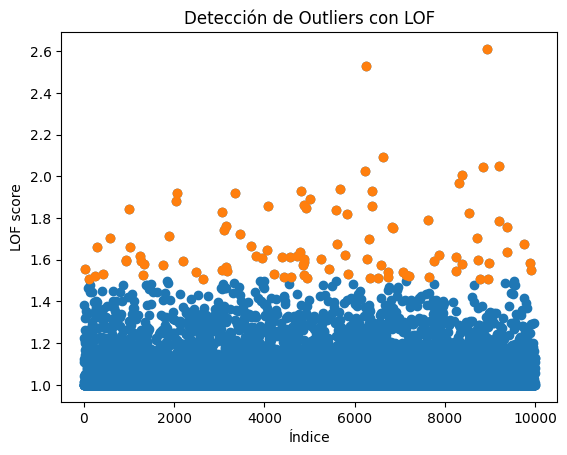

In [136]:
import matplotlib.pyplot as plt


threshold = 1.5

outliers = lof_scores > threshold

plt.figure()
plt.scatter(range(len(lof_scores)), lof_scores)
plt.scatter(np.where(outliers)[0], lof_scores[outliers])

plt.xlabel("Índice")
plt.ylabel("LOF score")
plt.title("Detección de Outliers con LOF")

plt.show()